In [ ]:
# GLOBAL TERRORISM DATA ANALYSIS PROJECT

"""
OBJECTIVE:
- Analyze terrorism trends from 1970–2017
- Identify most affected countries and regions
- Understand attack types and weapons used
- Study casualties and impact
- Generate insights useful for stakeholders
"""

'\nOBJECTIVE:\n- Analyze terrorism trends from 1970–2017\n- Identify most affected countries and regions\n- Understand attack types and weapons used\n- Study casualties and impact\n- Generate insights useful for stakeholders\n'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [1]:
from google.colab import files

# This will open a file picker dialog
uploaded = files.upload()

Saving Global Terrorism Data.csv to Global Terrorism Data.csv


In [3]:
import pandas as pd

df = pd.read_csv('/content/Global Terrorism Data.csv', encoding='latin1')

/tmp/ipykernel_1499/3683939806.py:3: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Global Terrorism Data.csv', encoding='latin1')


In [4]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df['nkill'] = df['nkill'].fillna(0)
df['nwound'] = df['nwound'].fillna(0)

In [6]:
df = df[['iyear','country_txt','region_txt','attacktype1_txt','weaptype1_txt','nkill','nwound']]

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

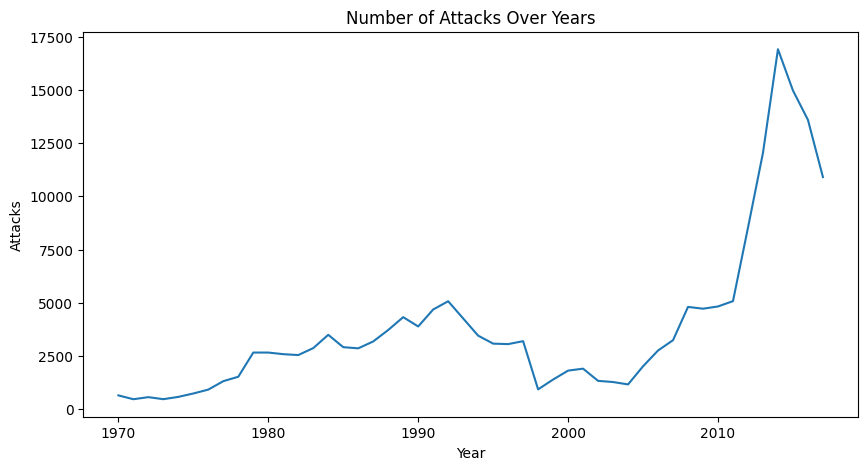

In [9]:
yearly = df['iyear'].value_counts().sort_index()

plt.figure(figsize=(10,5))
yearly.plot(kind='line')
plt.title("Number of Attacks Over Years")
plt.xlabel("Year")
plt.ylabel("Attacks")
plt.show()

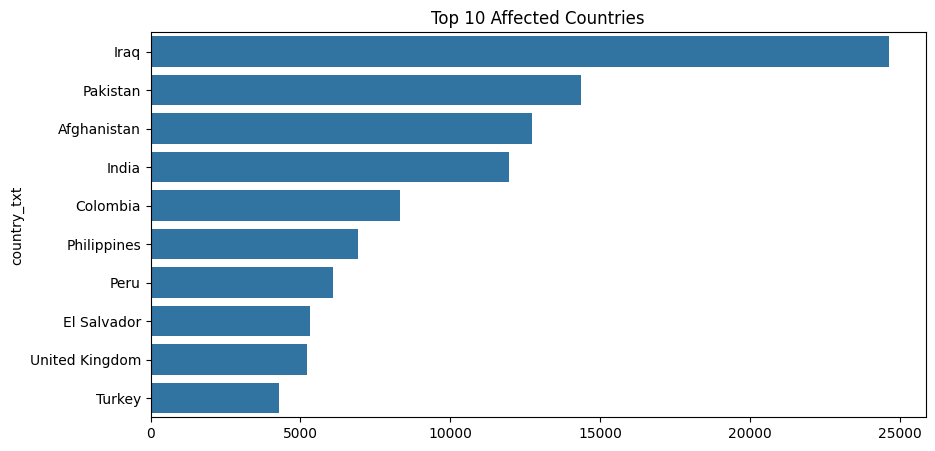

In [10]:
top_countries = df['country_txt'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Affected Countries")
plt.show()

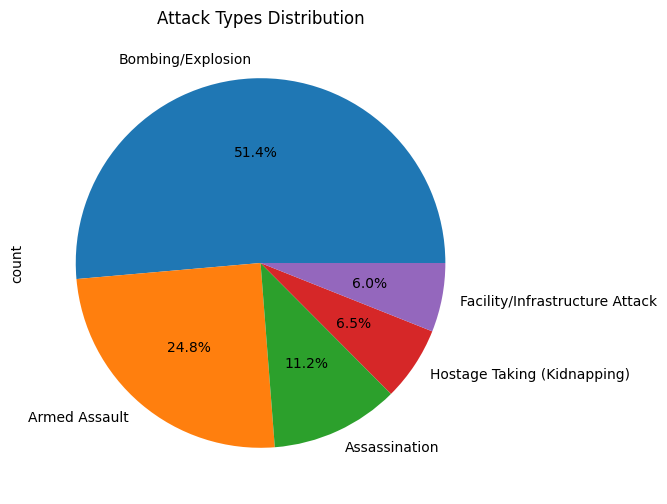

In [11]:
attack_types = df['attacktype1_txt'].value_counts().head(5)

plt.figure(figsize=(6,6))
attack_types.plot(kind='pie', autopct='%1.1f%%')
plt.title("Attack Types Distribution")
plt.show()

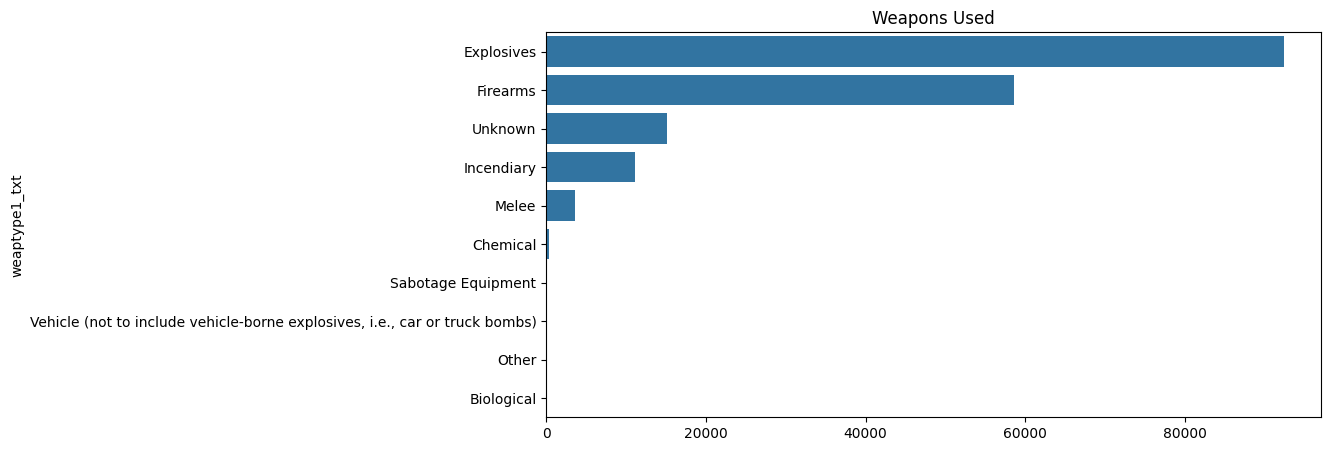

In [12]:
weapons = df['weaptype1_txt'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=weapons.values, y=weapons.index)
plt.title("Weapons Used")
plt.show()

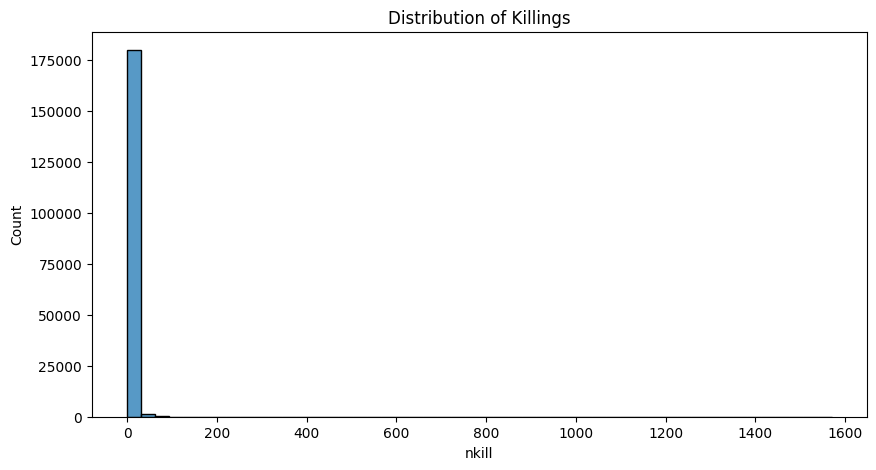

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['nkill'], bins=50)
plt.title("Distribution of Killings")
plt.show()

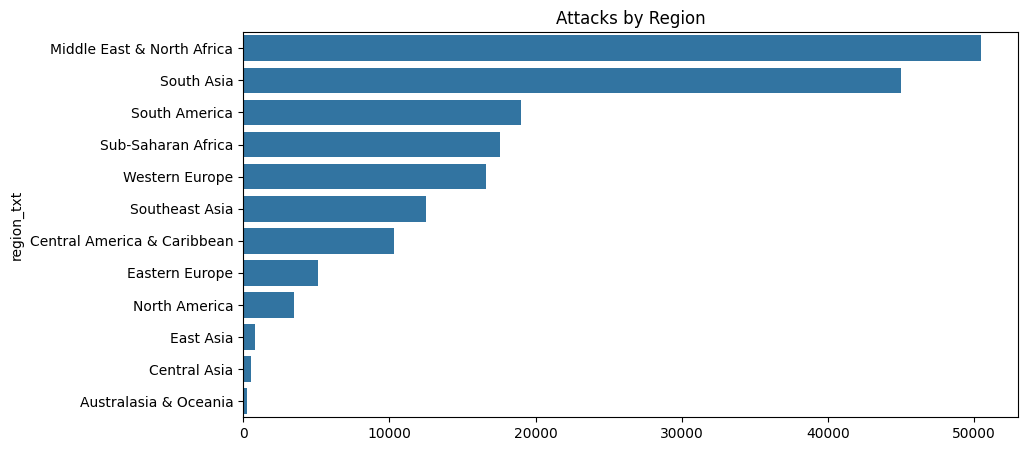

In [14]:
regions = df['region_txt'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=regions.values, y=regions.index)
plt.title("Attacks by Region")
plt.show()

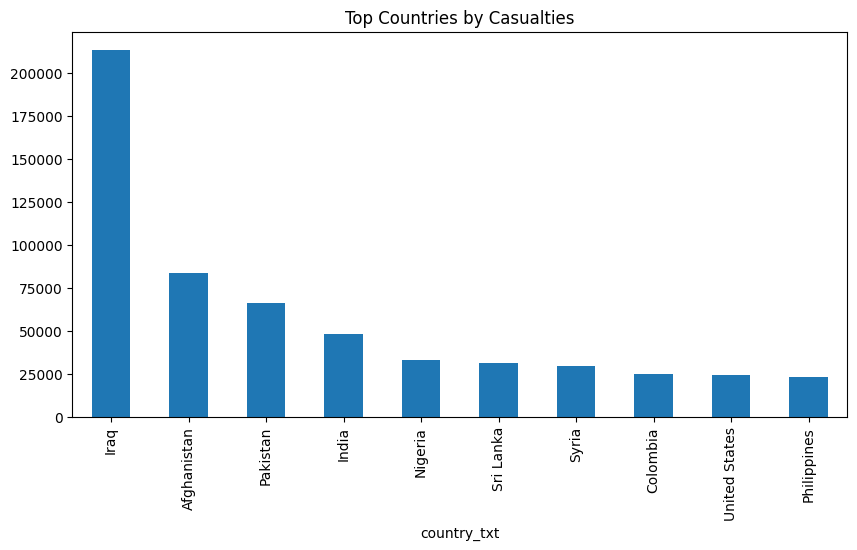

In [15]:
# Total Casualties by Country
df['casualties'] = df['nkill'] + df['nwound']

top_casualties = df.groupby('country_txt')['casualties'].sum().sort_values(ascending=False).head(10)

top_casualties.plot(kind='bar', figsize=(10,5), title="Top Countries by Casualties")
plt.show()